In [5]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [7]:
data=pd.read_csv("/content/drive/MyDrive/Datasets/INNHotelsGroup.csv")

In [8]:
data.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [10]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [11]:
print("--- Data Info ---")
print(data.info())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 1

/tmp/ipykernel_2260/4109725707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking_status', data=data, palette='Set2')


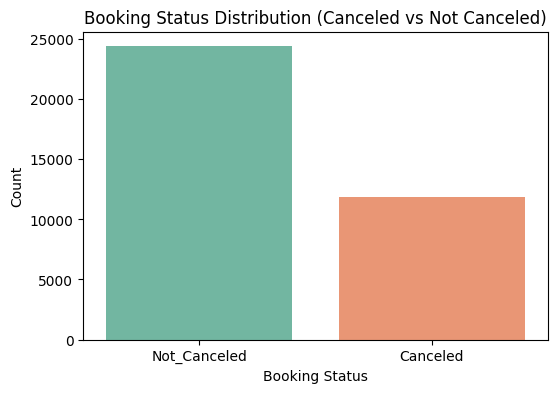

booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='booking_status', data=data, palette='Set2')
plt.title('Booking Status Distribution (Canceled vs Not Canceled)')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()

# Percentage dekhne ke liye
print(data['booking_status'].value_counts(normalize=True) * 100)

/tmp/ipykernel_2260/2570847334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='booking_status', y='lead_time', data=data, palette='Pastel1')


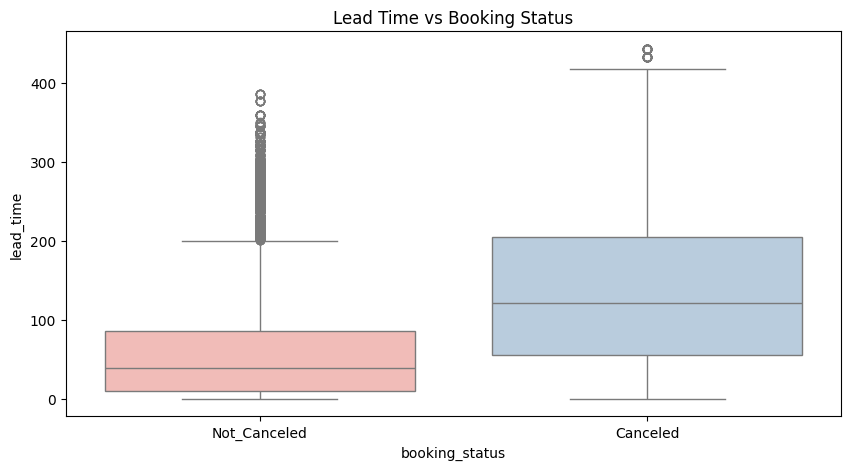

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='booking_status', y='lead_time', data=data, palette='Pastel1')
plt.title('Lead Time vs Booking Status')
plt.show()

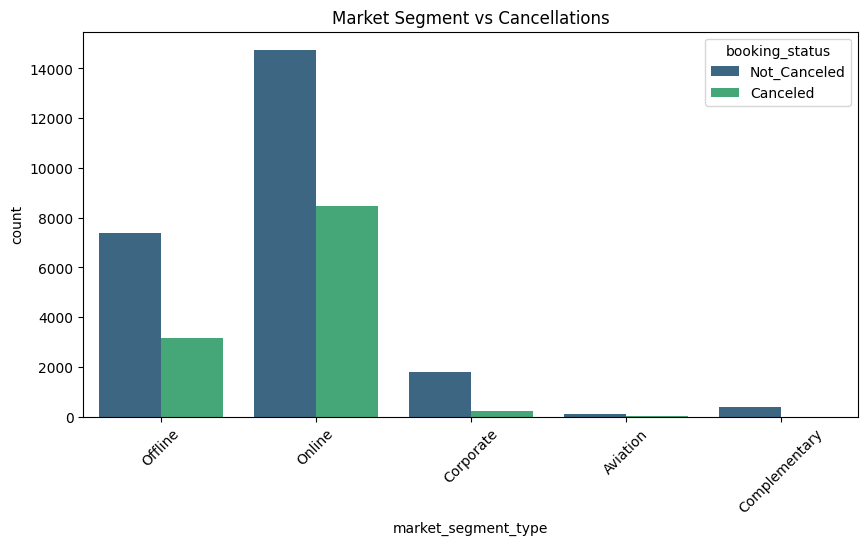

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='market_segment_type', hue='booking_status', data=data, palette='viridis')
plt.title('Market Segment vs Cancellations')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2260/3141828502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='booking_status', y='avg_price_per_room', data=data, palette='muted')


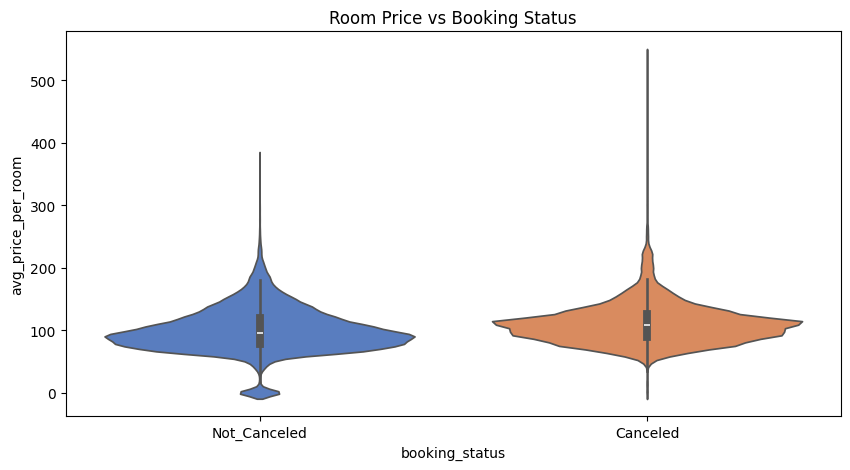

In [15]:
plt.figure(figsize=(10,5))
sns.violinplot(x='booking_status', y='avg_price_per_room', data=data, palette='muted')
plt.title('Room Price vs Booking Status')
plt.show()

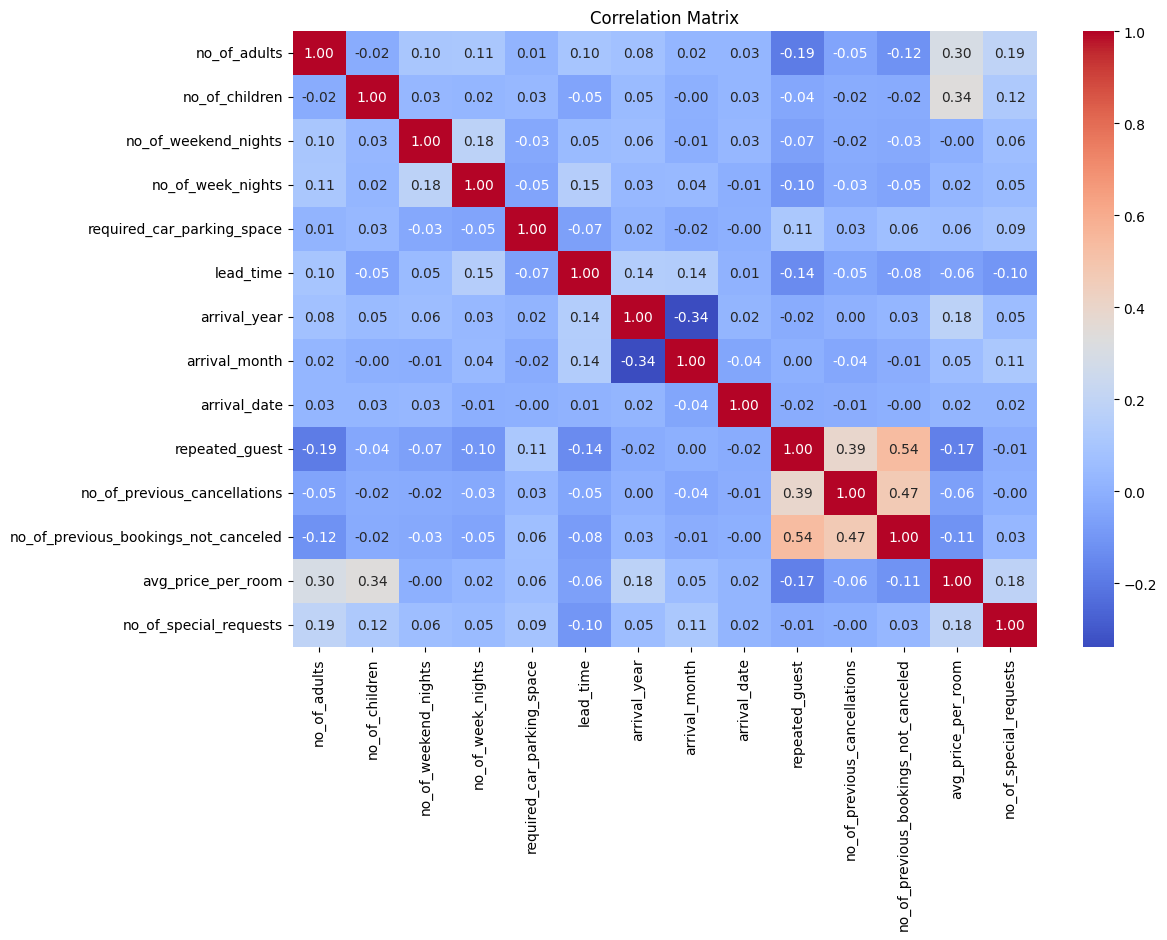

In [16]:
plt.figure(figsize=(12,8))
# Sirf numeric columns ka correlation nikalenge
numeric_df = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [19]:
# 1. Unnecessary columns hata dein (jaise Unique ID)
if 'Booking_ID' in data.columns:
    df = data.drop(['Booking_ID'], axis=1)

# 2. Categorical columns ko identify karein
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('booking_status') # Kyunki ye hamara target hai

# 3. One-Hot Encoding (Text ko numbers mein badalna)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Target variable ko 0 aur 1 mein badalna
df_encoded['booking_status'] = df_encoded['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

# 5. Features (X) aur Target (y) alag karein
X = df_encoded.drop('booking_status', axis=1)
y = df_encoded['booking_status']

# 6. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Feature Scaling (Kucch algorithms ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Models ki list/dictionary (Aapka same logic)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB()
}

# Results store karne ke liye list
model_performance = []

# Loop chalakar har model ko train aur test karenge
for name, model in models.items():
    # Scaling check
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # --- Metrics calculate karna ---
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)  # <-- Naya add kiya gaya hai
    f1 = f1_score(y_test, preds)

    # Results mein Recall ko bhi append karein
    model_performance.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Recall": round(rec, 4),           # <-- Table mein dikhane ke liye
        "F1-Score": round(f1, 4)
    })

# Results ko DataFrame mein convert karke display karna
# Hum results ko Recall ya F1-Score ke basis par sort kar sakte hain
results_df = pd.DataFrame(model_performance).sort_values(by="Recall", ascending=False)

print("\n--- Final Model Comparison Table ---")
print(results_df.to_string(index=False))

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_r')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy (%)')
plt.xlim(60, 100) # Graph ko clear dekhne ke liye range set ki
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Example: Categorical columns ko encode karna
# (Aap pd.get_dummies() ka use bhi kar sakte hain)

# Features (X) aur Target (y) ko alag karein
X = df.drop(['Booking_ID', 'booking_status'], axis=1)
y = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

# Data ko Train aur Test sets mein baantein (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, f1_score

# 1. Models ki ek dictionary bana lein
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB()
}

# 2. Loop chala kar saare models ko train aur test karein
results = {}
for name, model in models.items():
    # KNN, Logistic Regression aur SVM ke liye scaled data use karein
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        # Decision Tree, Random Forest aur Naive Bayes bina scaling ke bhi chal sakte hain
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    # Accuracy aur F1-Score calculate karein
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results[name] = {"Accuracy": acc, "F1-Score": f1}

# Results ko table format mein dekhne ke liye DataFrame banayein
results_df = pd.DataFrame(results).T
print(results_df)